Sztuczne sieci neuronowe i algorytmy uczenia głębokiego | Pracownia specjalistyczna 5-6 - Perceptron wielowarstwowy

Adam Dobrogowski PS7

----------------------------------------

Zadanie nr 1

Wykorzystując poniższy kod utwórz perceptron wielowarstwowy do analizy zbioru MNIST. Przeanalizuj poszczególne fragmenty kodu.


In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

mnist = tf.keras.datasets.mnist 

(x_train,  y_train), (x_test, y_test) = mnist.load_data()

In [2]:
print(f"Wymiar danych uczących (x_train): {x_train.shape}")
print(f"Wymiar etykiet uczących (y_train): {y_train.shape}")
print(f"Wymiar danych testowych (x_test): {x_test.shape}")

Wymiar danych uczących (x_train): (60000, 28, 28)
Wymiar etykiet uczących (y_train): (60000,)
Wymiar danych testowych (x_test): (10000, 28, 28)


1. Jaki jest wymiar danych uczących i testowych?  Dane uczące to 60 000 obrazów 28x28, dane testowe to 10 000 obrazów o tym samym rozmiarze.
--------------------------------
2. Narysuj dowolny obraz z danych uczących oraz wyświetl informację o wartości wzorca dla
tego obrazu:


Text(0.5, 1.0, 'Wartość wzorca (etykieta): 5')

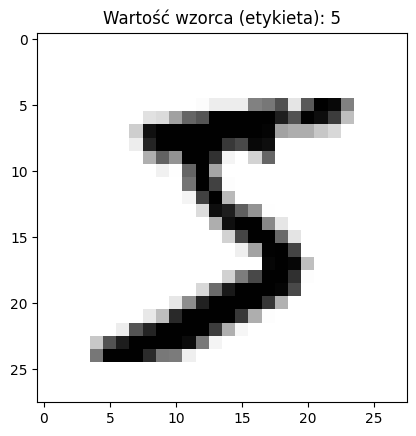

In [3]:
plt.imshow(x_train[0], cmap=plt.cm.binary) 
plt.title(f"Wartość wzorca (etykieta): {y_train[0]}") 

----------------------------------

In [5]:
x_train = tf.keras.utils.normalize(x_train, axis=1)
x_test = tf.keras.utils.normalize(x_test, axis=1)

model = tf.keras.models.Sequential() 

model.add(tf.keras.layers.Flatten(input_shape=(28, 28)))
model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dense(128, activation='relu'))

model.add(tf.keras.layers.Dense(10, activation='softmax'))

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']) 

model.summary()

C:\Users\Adam\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,282 (462.04 KB)

 Trainable params: 118,282 (462.04 KB)

 Non-trainable params: 0 (0.00 B)

3. Podaj następujące parametry sieci: liczba warstw, liczba elementów w poszczególnych
warstwach, funkcja aktywacji, algorytm optymalizacji, funkcja celu oraz miara oceny modelu:
- liczba warstw: 4
- liczba elementów w poszczególnych warstwach: Wejściowa: 
    - 784 neurony (wynik spłaszczenia 28x28).
    - Ukryte: po 128 neuronów każda.
    - Wyjściowa: 10 neuronów (odpowiadających cyfrom 0-9).
- funkcja aktywacji: ReLU w warstwach ukrytych oraz Softmax w warstwie wyjściowej.
- algorytm optymalizacji: Adam
- funkcja celu: Sparse Categorical Crossentropy
- miara oceny modelu: Accuracy


------------------------------

In [6]:
model.fit(x_train, y_train, batch_size=1, epochs=3)

val_loss, val_acc = model.evaluate(x_test, y_test)

print(f"Wartość funkcji celu (loss) na zbiorze testowym: {val_loss}")
print(f"Jakość klasyfikacji (accuracy) na zbiorze testowym: {val_acc}")

Epoch 1/3
60000/60000 ━━━━━━━━━━━━━━━━━━━━ 38s 626us/step - accuracy: 0.9337 - loss: 0.2239
Epoch 2/3
60000/60000 ━━━━━━━━━━━━━━━━━━━━ 38s 637us/step - accuracy: 0.9639 - loss: 0.1363
Epoch 3/3
60000/60000 ━━━━━━━━━━━━━━━━━━━━ 38s 634us/step - accuracy: 0.9698 - loss: 0.1222
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 582us/step - accuracy: 0.9596 - loss: 0.1889
Wartość funkcji celu (loss) na zbiorze testowym: 0.1889325976371765
Jakość klasyfikacji (accuracy) na zbiorze testowym: 0.9595999717712402


4. Naucz sieć. Jaka jest jakość klasyfikacji otrzymanej sieci oraz wartość funkcji celu?
- Wartość funkcji celu (loss) na zbiorze testowym: 0.1889
- Jakość klasyfikacji (accuracy) na zbiorze testowym: 0.9596

------------------------------------------

In [7]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, 
                    epochs=10, 
                    batch_size=1, 
                    validation_data=(x_test, y_test))


Epoch 1/10
60000/60000 ━━━━━━━━━━━━━━━━━━━━ 42s 701us/step - accuracy: 0.9346 - loss: 0.2238 - val_accuracy: 0.9545 - val_loss: 0.1646
Epoch 2/10
60000/60000 ━━━━━━━━━━━━━━━━━━━━ 42s 703us/step - accuracy: 0.9632 - loss: 0.1391 - val_accuracy: 0.9605 - val_loss: 0.1486
Epoch 3/10
60000/60000 ━━━━━━━━━━━━━━━━━━━━ 42s 704us/step - accuracy: 0.9697 - loss: 0.1244 - val_accuracy: 0.9602 - val_loss: 0.1861
Epoch 4/10
60000/60000 ━━━━━━━━━━━━━━━━━━━━ 42s 701us/step - accuracy: 0.9715 - loss: 0.1171 - val_accuracy: 0.9646 - val_loss: 0.1945
Epoch 5/10
60000/60000 ━━━━━━━━━━━━━━━━━━━━ 43s 720us/step - accuracy: 0.9744 - loss: 0.1106 - val_accuracy: 0.9692 - val_loss: 0.1955
Epoch 6/10
60000/60000 ━━━━━━━━━━━━━━━━━━━━ 43s 709us/step - accuracy: 0.9767 - loss: 0.1022 - val_accuracy: 0.9589 - val_loss: 0.2405
Epoch 7/10
60000/60000 ━━━━━━━━━━━━━━━━━━━━ 42s 706us/step - accuracy: 0.9779 - loss: 0.1044 - val_accuracy: 0.9703 - val_loss: 0.2278
Epoch 8/10
60000/60000 ━━━━━━━━━━━━━━━━━━━━ 42s 706us/s

In [9]:
val_loss, val_acc = model.evaluate(x_test, y_test)
print(f"Finalna dokładność po 10 epokach: {val_acc}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 574us/step - accuracy: 0.9692 - loss: 0.2509
Finalna dokładność po 10 epokach: 0.9692000150680542


5. Zmień liczbę epok na 10 i ponownie wykonaj obliczenia. Czy zwiększenie liczby epok zmieniło
jakość modelu?



- Accuracy wzrosło do 0.9692: Zwiększenie liczby epok faktycznie poprawiło jakość modelu
- Loss: Zaczęła rosnąć po drugiej epoce (z 0.1486 na 0.2509), mimo że na zbiorze uczącym ciągle malała - overfitting

---------------------------------

6. Wykonaj zmiany w kodzie, aby umożliwić obserwację procesu uczenia (jakości sieci) w
poszczególnych epokach na bazie zbioru uczącego oraz testowego. Narysuj wykres.

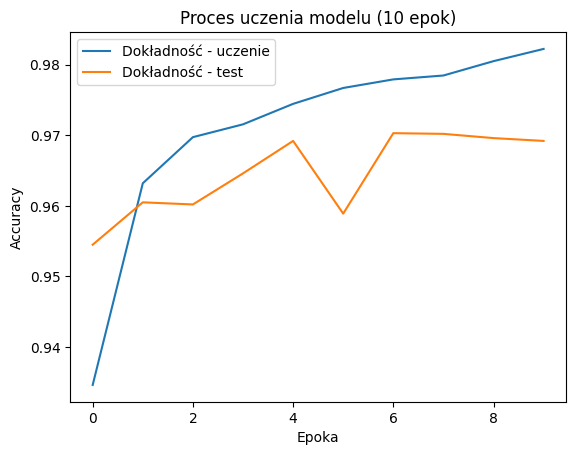

In [10]:
plt.plot(history.history['accuracy'], label='Dokładność - uczenie')
plt.plot(history.history['val_accuracy'], label='Dokładność - test')
plt.title('Proces uczenia modelu (10 epok)')
plt.xlabel('Epoka')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Zwiększenie liczby epok do 10 znacząco podniosło dokładność na zbiorze uczącym, lecz zastosowanie parametru batch_size=1 skutkowało bardzo niestabilnym procesem uczenia na zbiorze testowym. Rosnąca po 6. epoce rozbieżność między krzywymi świadczy o wystąpieniu przeuczenia się sieci.
  

--------------------------------------

7. Ustaw parametr validation_split, tak aby w trakcie uczenia 30 procent zbioru uczącego było
zbiorem do walidacji. Narysuj wykres procesu uczenia oraz podaj otrzymane wartości jakości
klasyfikacji dla zbioru testowego i uczącego

Epoch 1/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9110 - loss: 0.3088 - val_accuracy: 0.9512 - val_loss: 0.1639
Epoch 2/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9620 - loss: 0.1232 - val_accuracy: 0.9588 - val_loss: 0.1407
Epoch 3/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9743 - loss: 0.0827 - val_accuracy: 0.9646 - val_loss: 0.1133
Epoch 4/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9814 - loss: 0.0594 - val_accuracy: 0.9611 - val_loss: 0.1367
Epoch 5/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9851 - loss: 0.0456 - val_accuracy: 0.9654 - val_loss: 0.1203
Epoch 6/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9888 - loss: 0.0334 - val_accuracy: 0.9659 - val_loss: 0.1341
Epoch 7/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9910 - loss: 0.0272 - val_accuracy: 0.9664 - val_loss: 0.1327
Epoch 8/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9916 - loss: 0.0247 - 

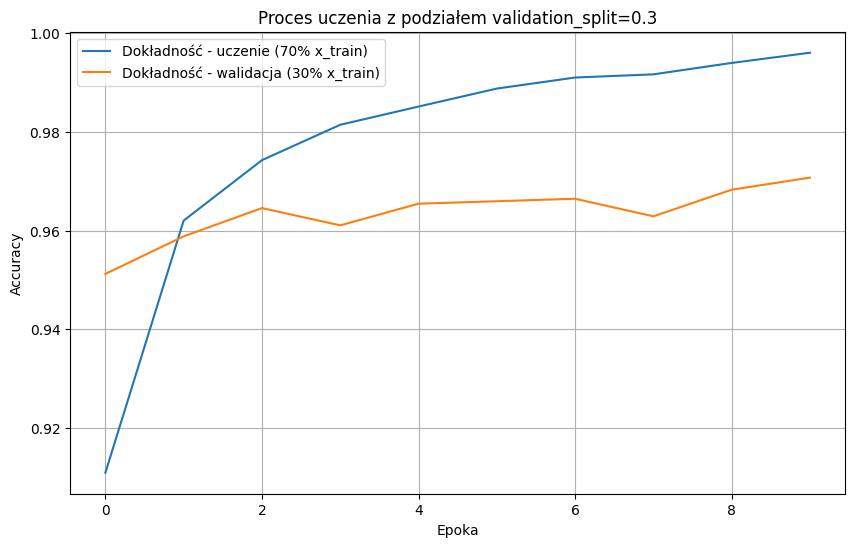

Jakość klasyfikacji dla zbioru uczącego (ostatnia epoka): 0.9960
Jakość klasyfikacji dla zbioru testowego (x_test): 0.9716


In [12]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, 
                    epochs=10, 
                    batch_size=32, 
                    validation_split=0.3,
                    verbose=1)

plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Dokładność - uczenie (70% x_train)')
plt.plot(history.history['val_accuracy'], label='Dokładność - walidacja (30% x_train)')
plt.title('Proces uczenia z podziałem validation_split=0.3')
plt.xlabel('Epoka')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

print(f"Jakość klasyfikacji dla zbioru uczącego (ostatnia epoka): {history.history['accuracy'][-1]:.4f}")
print(f"Jakość klasyfikacji dla zbioru testowego (x_test): {test_acc:.4f}")

Wprowadzenie validation_split=0.3 oraz zwiększenie batch_size do 32 znacząco wygładziło krzywe uczenia, zapewniając stabilniejsze uczenie modelu.

Uzyskano bardzo wysoka dokładność na zbiorze uczącym (0,9960) przy lekko niższym wyniku testowym (0,9716)

--------------------------------

8. Zmień liczbę neuronów w warstwach. Sprawdź wpływ tej operacji na działanie sieci.

In [16]:
konfiguracje = [32, 512]

for n_neurons in konfiguracje:
    print(f"\nModel z {n_neurons} neuronami w warstwach ukrytych")
    
    model = tf.keras.models.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(n_neurons, activation='relu'),
        tf.keras.layers.Dense(n_neurons, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    history = model.fit(x_train, y_train, 
                        epochs=5, 
                        batch_size=32, 
                        validation_split=0.3,
                        verbose=1)

    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    
    print(f"WYNIK DLA {n_neurons} NEURONÓW:")
    print(f"Accuracy (Uczenie): {history.history['accuracy'][-1]:.4f}")
    print(f"Accuracy (Test): {test_acc:.4f}")
    print(f"Różnica: {abs(history.history['accuracy'][-1] - test_acc):.4f}")


Model z 32 neuronami w warstwach ukrytych
Epoch 1/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 877us/step - accuracy: 0.8742 - loss: 0.4546 - val_accuracy: 0.9161 - val_loss: 0.2876
Epoch 2/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 814us/step - accuracy: 0.9339 - loss: 0.2279 - val_accuracy: 0.9321 - val_loss: 0.2251
Epoch 3/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 804us/step - accuracy: 0.9457 - loss: 0.1828 - val_accuracy: 0.9427 - val_loss: 0.1921
Epoch 4/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 823us/step - accuracy: 0.9541 - loss: 0.1528 - val_accuracy: 0.9417 - val_loss: 0.1914
Epoch 5/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1s 810us/step - accuracy: 0.9590 - loss: 0.1335 - val_accuracy: 0.9472 - val_loss: 0.1762
WYNIK DLA 32 NEURONÓW:
Accuracy (Uczenie): 0.9590
Accuracy (Test): 0.9520
Różnica: 0.0070

Model z 512 neuronami w warstwach ukrytych
Epoch 1/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9303 - loss: 0.2315 - val_accuracy: 0.9574 - val_loss: 0.1368
Epoch 2/5
1313/1313 ━━━━━━━━━━━━━━━━━━━

Czy zmniejszenie/zwiększenie liczby neuronów miało wpływ na jakość klasyfikacji?  
- Zwiększenie ich liczby do 512 pozwoliło sieci na uchwycenie bardziej złożonych cech obrazów, co przełożyło się na wyższą precyzję końcową na obu zbiorach danych, jednak bardziej zaawansowana struktura sieci prowadziła do zwiększenia tendencji do overfittingu. 
- Zmniejszenie liczby neuronów do 32 ograniczyło możliwości sieci, co skutkowało niższą dokładnością, ale zapewniło większą spójność między wynikami uczącymi a testowymi.

----------------------------------

Zadanie nr 2

Na bazie zbioru MNIST przenalizuj wpływ parametru batch_size na szybkość uczenia oraz na jakość
klasyfikacji.

In [ ]:
import time 

batches = [1, 64, 256, 1024]
results = {}

batches = [1, 64, 1024]
results = {}

for b_size in batches:
    print(f"\n>>> Testowanie batch_size = {b_size} <<<")
    
    # Tworzymy świeży model
    model = tf.keras.models.Sequential([
        tf.keras.Input(shape=(28, 28)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    # Pomiar czasu start (Pomoc [cite: 62])
    start = time.time()
    
    # Trenujemy tylko 1 epokę, aby szybko zobaczyć różnice w czasie
    history = model.fit(x_train, y_train, epochs=1, batch_size=b_size, verbose=1)
    
    # Pomiar czasu koniec (Pomoc [cite: 63])
    end = time.time()
    duration = end - start
    
    # Sprawdzamy jakość na zbiorze testowym
    _, test_acc = model.evaluate(x_test, y_test, verbose=0)
    
    results[b_size] = {'czas': duration, 'accuracy': test_acc}

# Podsumowanie wyników
print("\n--- PODSUMOWANIE EKSPERYMENTU ---")
for b, data in results.items():
    print(f"Batch {b:4} | Czas: {data['czas']:6.2f}s | Jakość: {data['accuracy']:.4f}")